In [80]:
import pandas as pd
from CCA_utils import *

##Baseline Model panel:

In [101]:
study_sovereigns = [
    'Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Qatar', 'Colombia',
    'Mexico', 'Brazil', 'Egypt', 'Malaysia','Indonesia', 'Philippines', 'Turkey', 'Chile', 'China',
    'South Africa', 'South Korea', 'Thailand']

cca_panel_df = pd.read_csv('../data/processed/CCA/cca_newfx_rates.csv')
cca_panel_df['date'] = pd.to_datetime(cca_panel_df['date'])
cca_panel_df = cca_panel_df[cca_panel_df['country'].isin(study_sovereigns)].copy()
cca_panel_df.drop(columns=['cds_spread_1Y'], inplace=True)
cca_panel_df.rename(columns={'cds_spread_5Y': 'cds_spread'}, inplace=True)


T=1.0
vol_window = 52
freq = 'W'

cca_panel_df.set_index(['date','country'], inplace=True)
cca_panel_df = (
    cca_panel_df
    .groupby('country')
    .resample(freq, level='date')
    .last()
)
cca_panel_df.reset_index(inplace=True)
cca_panel_df['domestic_rate_in_units'] = cca_panel_df['domestic_rate_in_units']/100
cca_panel_df['risk_free_rate'] = cca_panel_df['risk_free_rate']/100
cca_panel_df['monetary_base_mn_localcurr'] = cca_panel_df['monetary_base_mn_localcurr'] / 1000
cca_panel_df['domestic_debt_bn_localcurr'] = cca_panel_df['domestic_debt_bn_localcurr'] 
cca_panel_df['external_debt_mn_usd'] = cca_panel_df['external_debt_mn_usd']/1000


In [ ]:
results = pd.DataFrame()

for country, group in cca_panel_df.groupby('country'):

    df = group.copy().sort_values('date').reset_index(drop=True)
    
    # --- Unit conversions ---
    r_d = df['domestic_rate_in_units']
    r_f = df['risk_free_rate']
    M_bn = df['monetary_base_mn_localcurr']
    dom_D_bn = df['domestic_debt_bn_localcurr']
    ext_D_bn = df['external_debt_mn_usd']
    fx_rate = df['fx_rate']


    # --- LCL$ ---
    df['LCL_usd'] = [
        compute_lcl_usd(m, bd, fx, rd, rf, T)
        for m, bd, fx, rd, rf in zip(
            M_bn, dom_D_bn, fx_rate, r_d, r_f
        )
    ]

    ann_factor = np.sqrt(52) if freq == 'W' else np.sqrt(12)
    log_ret = np.log(df['LCL_usd'] / df['LCL_usd'].shift(1))
    df['sigma_lcl'] = log_ret.rolling(window=vol_window).std() * ann_factor
    
    # --- Barrier ---
    df['B_f'] = [
            compute_barrier_kvm(debt, rf, T)
            for debt, rf in zip(
                ext_D_bn, r_f
            )
        ]
    
    # --- Solve CCA for each week ---
    out = {'implied_V': [], 'implied_sigma_V': [], 'cca_converged': [],
           'distance_to_distress': [], 'default_prob': [],
           'model_spread_bps': [], 'put_value': [], 'risky_debt': [],
           'leverage': []}
    
    for i, row in df.iterrows():
        cca = solve_CCA(row['LCL_usd'], row['sigma_lcl'], row['B_f'],
                        r_f.iloc[i], T)
        

        risk = compute_risk(cca['V'], cca['sigma_V'], row['B_f'],
                            r_f.iloc[i], T)
        
        out['implied_V'].append(cca['V'])
        out['implied_sigma_V'].append(cca['sigma_V'])
        out['cca_converged'].append(cca['converged'])
        out['distance_to_distress'].append(risk['d2'])
        out['default_prob'].append(risk['default_prob'])
        out['model_spread_bps'].append(risk['credit_spread_bps'])
        out['put_value'].append(risk['put_value'])
        out['risky_debt'].append(risk['risky_debt'])
        out['leverage'].append(risk['leverage'])
    
    for col, vals in out.items():
        df[col] = vals

    results = pd.concat([results, df])



    START_DATE = '2015-01-01'
    END_DATE = '2019-12-31'

    results = results[
        (results['date'] >= START_DATE) & (results['date'] <= END_DATE)
    ].copy()

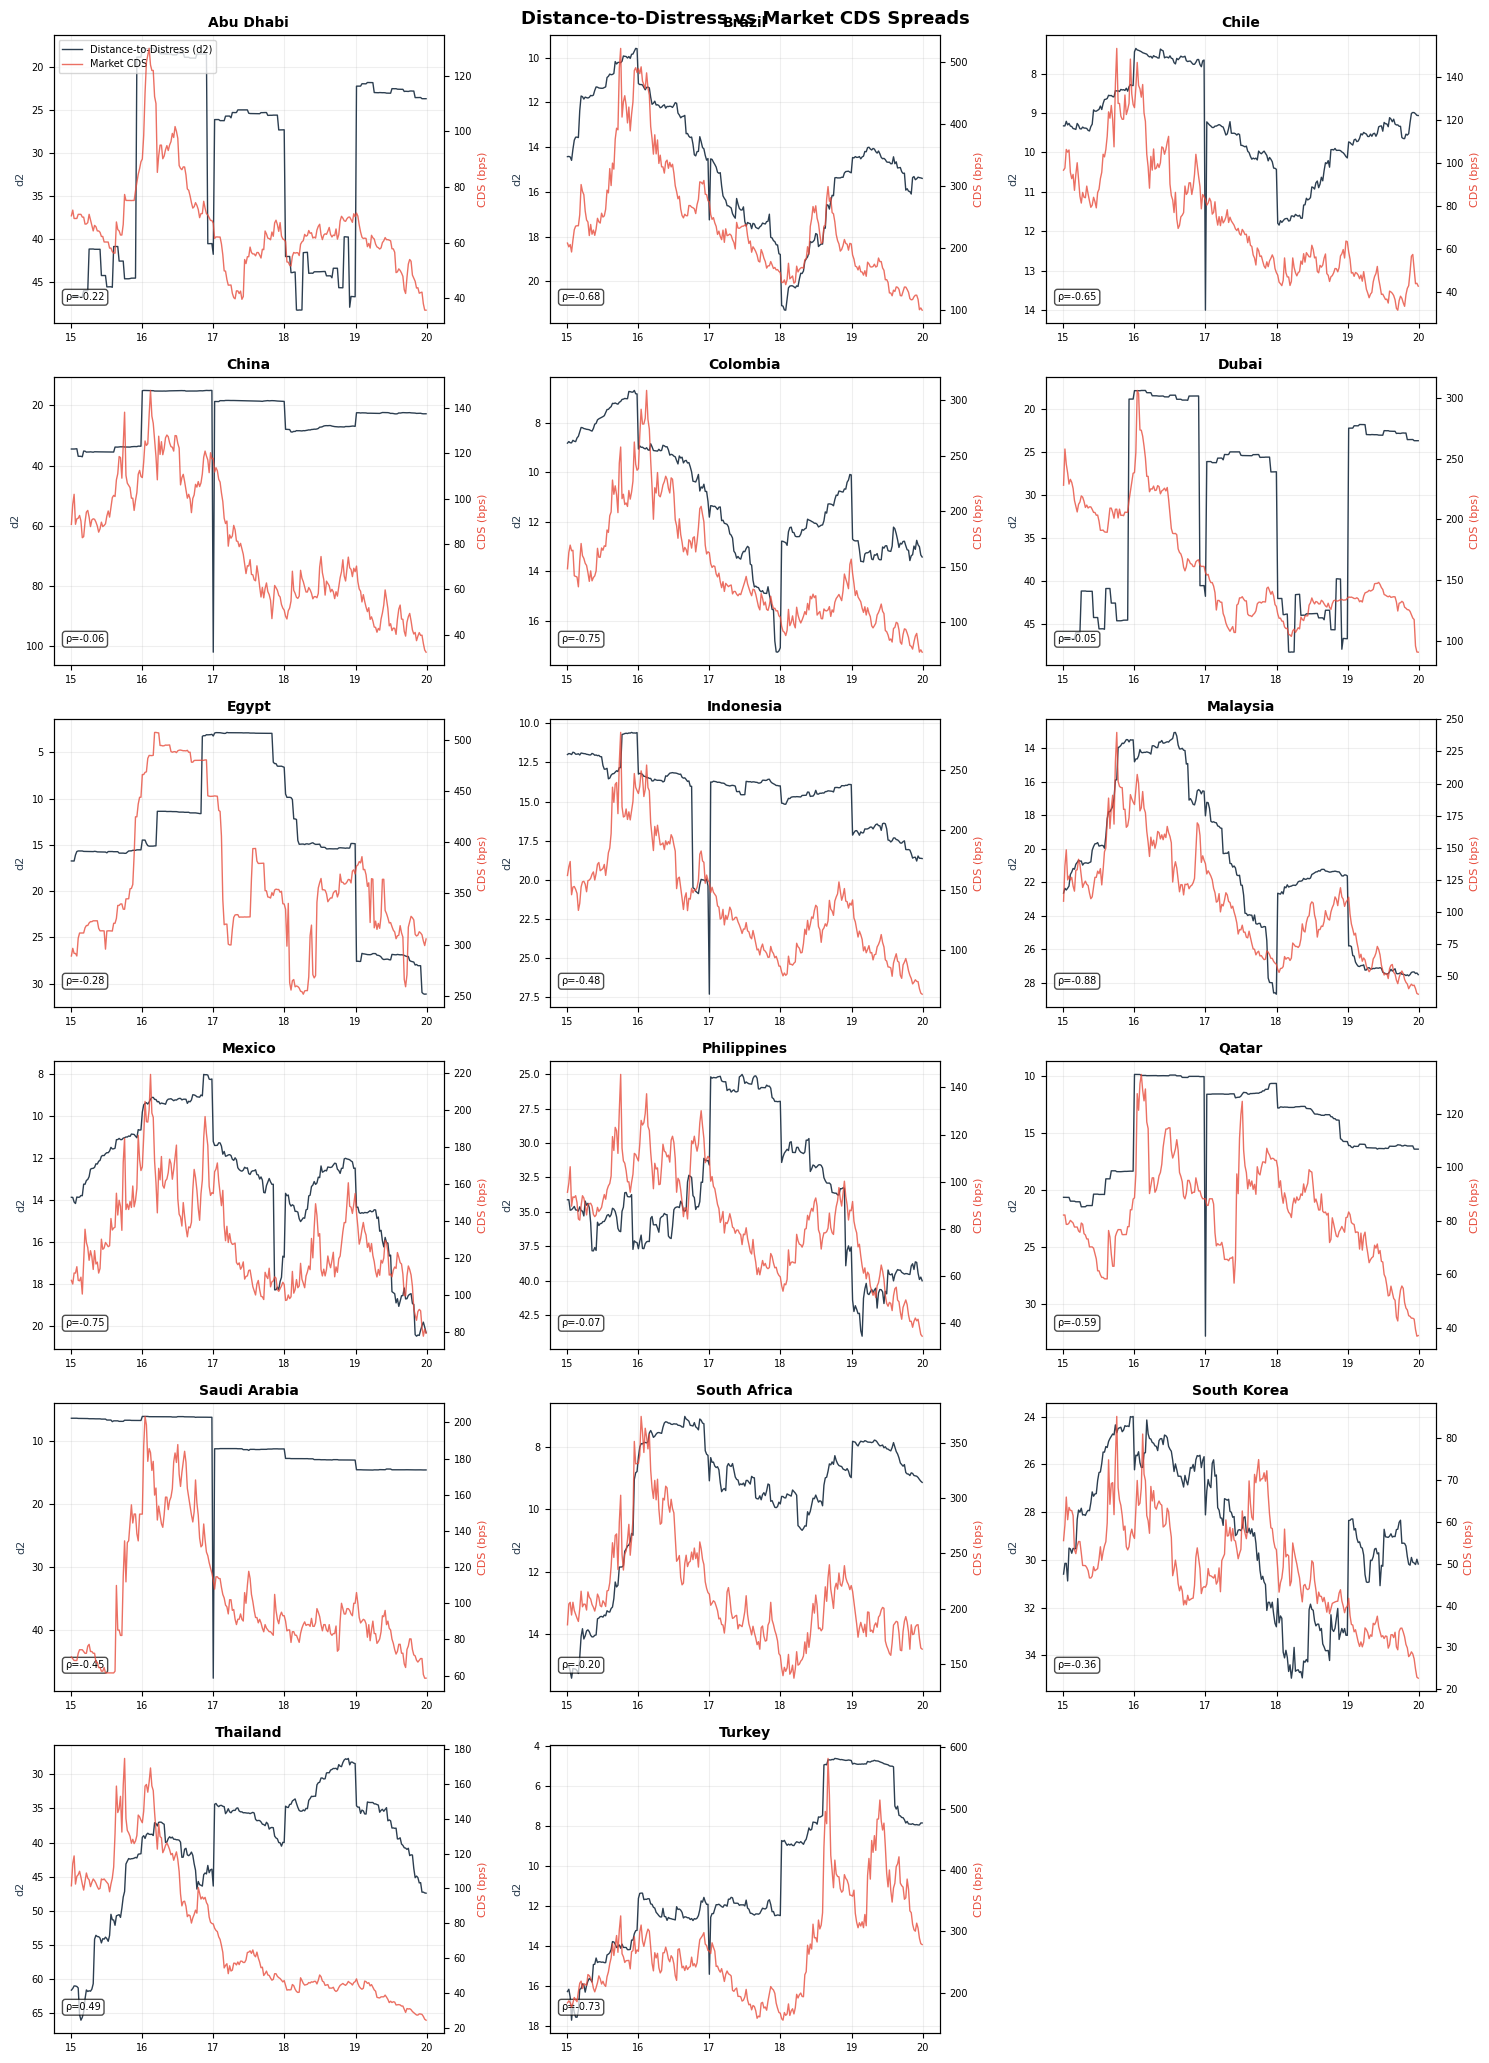

In [104]:
d2_vs_cds = plot_d2_vs_cds(results)

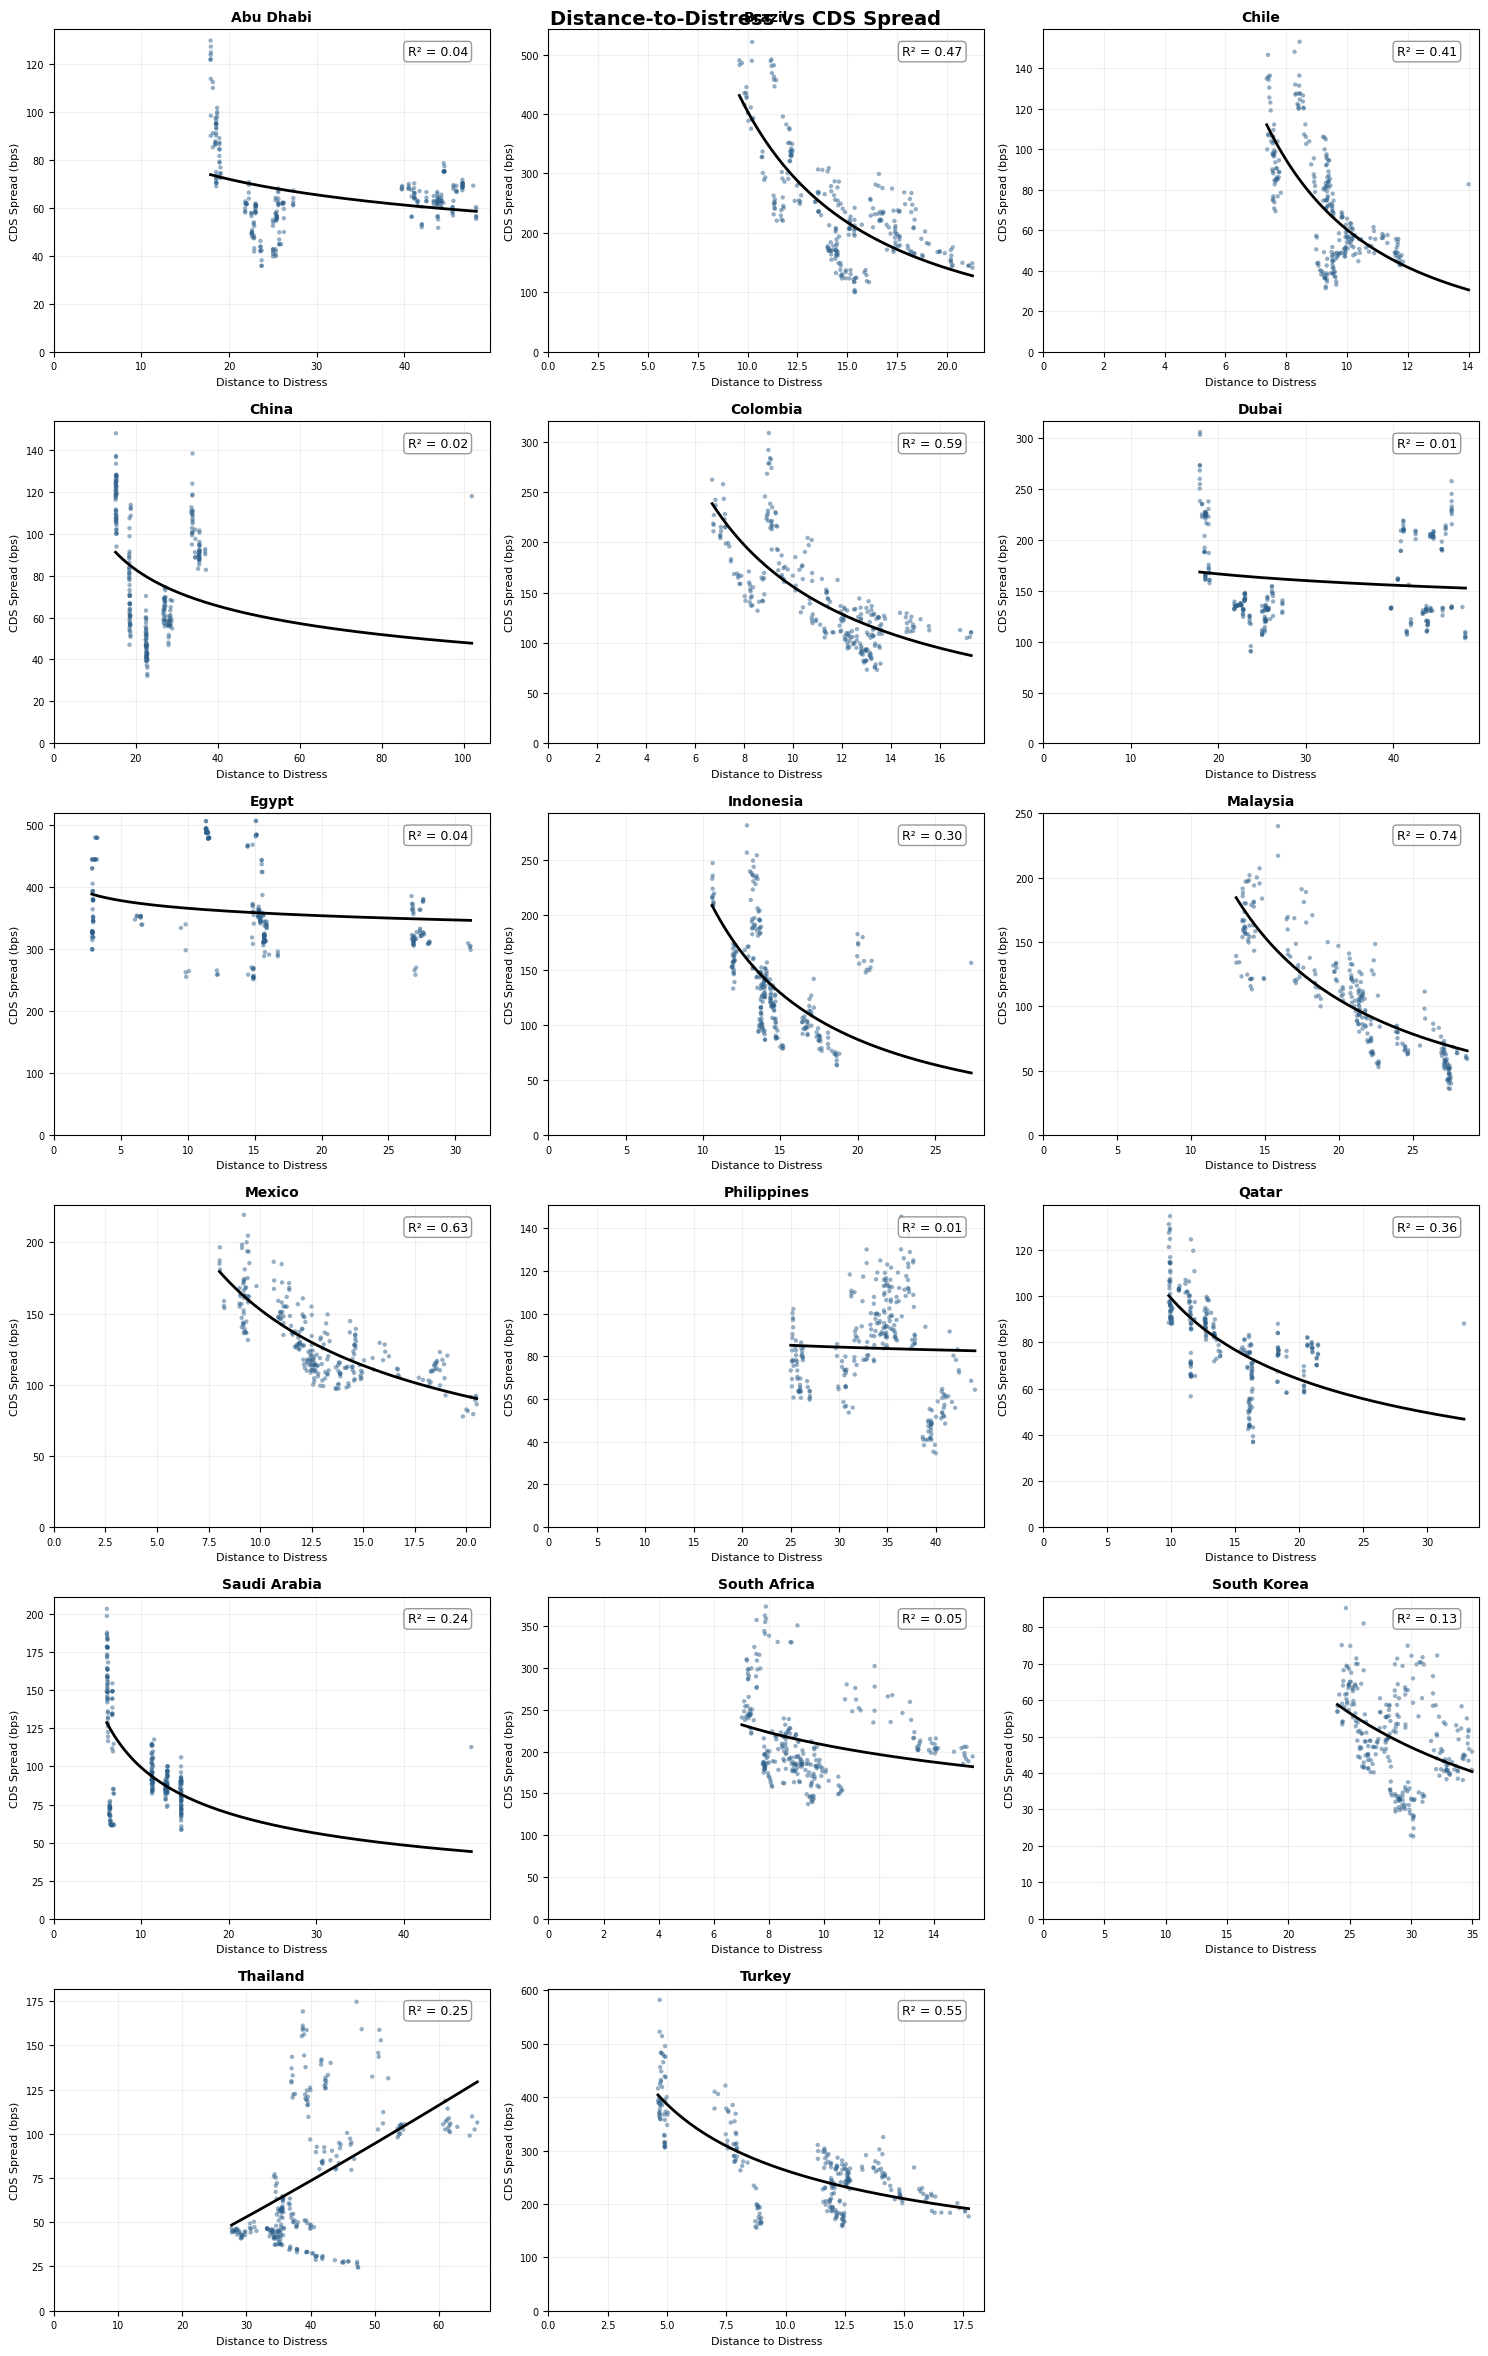

In [105]:
d2_scatter = plot_d2_scatter(results)

In [108]:
display, raw = correlation_table(
    results,
    dd_col='distance_to_distress',
    horizons=[1, 4, 12],
    horizon_labels=['1w', '1m', '3m'],
)
display

,Country,N,ρ (1w),Dir (1w),ρ (1m),Dir (1m),ρ (3m),Dir (3m)
0,Abu Dhabi,261,-0.01,46%,-0.12*,50%,-0.32***,51%
1,Brazil,261,-0.19***,63%,-0.34***,69%,-0.36***,67%
2,Chile,261,-0.04,64%,-0.14**,61%,-0.22***,61%
3,China,261,0.05,55%,-0.01,60%,-0.04,59%
4,Colombia,261,-0.07,61%,-0.04,70%,-0.09,66%
5,Dubai,261,-0.09,49%,-0.18***,61%,-0.39***,49%
6,Egypt,261,0.01,53%,-0.02,57%,-0.09,53%
7,Indonesia,261,0.06,60%,0.05,61%,0.14**,56%
8,Malaysia,261,-0.03,60%,-0.18***,62%,-0.43***,66%
9,Mexico,261,-0.08,57%,-0.16***,59%,-0.36***,73%


In [ ]:
results.to_csv("../output/results/M0_results.csv")